In [7]:
# =============================================================================
#  HyperShield — Unified Anti-Ransomware AI Pipeline
#  Combines data preparation, unsupervised analysis, supervised classification,
#  and ensemble anomaly detection in a single, reproducible script.
#
#  Required packages (run once before executing):
#    pip install pandas numpy matplotlib seaborn scikit-learn xgboost pyod shap torch
# =============================================================================

# --- INSTALL REQUIRED PACKAGES ---
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost pyod shap torch

# ── Colab: mount Drive FIRST so all outputs are persisted ────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/HyperShield/'
    import os; os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"[Colab] Drive mounted. Outputs → {OUTPUT_DIR}")
except ImportError:
    OUTPUT_DIR = './'
    print("[Local] Running locally. Outputs → current directory")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Colab] Drive mounted. Outputs → /content/drive/MyDrive/HyperShield/


In [8]:
pip install xgboost shap

In [9]:
pip install shap

In [10]:
# =============================================================================
#  SECTION 0 — Imports
# =============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

import xgboost as xgb

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.ecod import ECOD
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS
from pyod.utils.utility import standardizer

import shap

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [11]:
pip install PyOD


SECTION 1 — DATA LOADING & CLEANING
Raw dataset shape   : (21752, 77)
Columns             : ['md5', 'sha1', 'file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'text_Characteristics', '

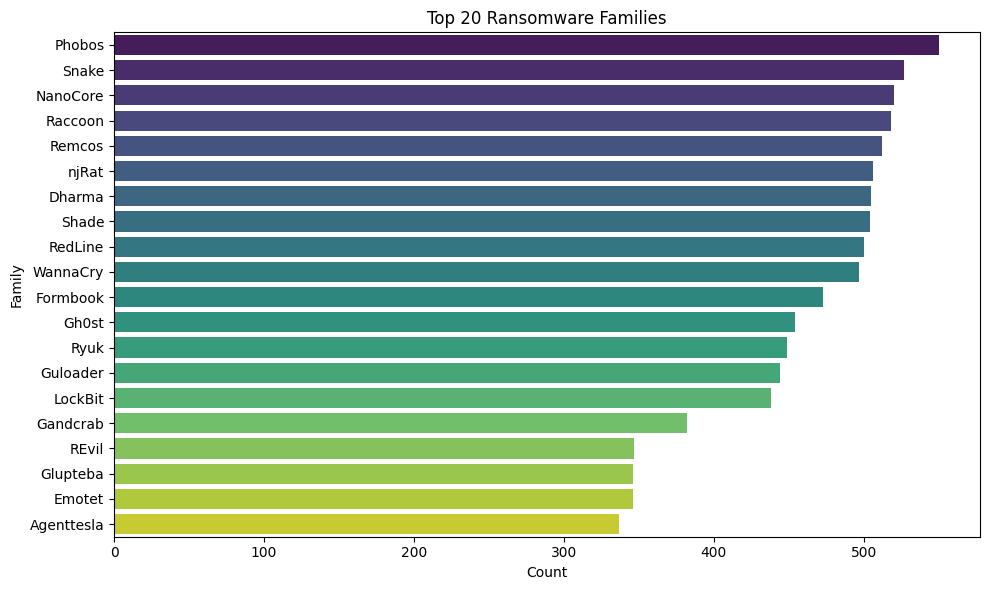

Saved family_distribution.png


In [12]:
# =============================================================================
#  SECTION 1 — Data Loading & Cleaning
# =============================================================================
print("\n" + "="*70)
print("SECTION 1 — DATA LOADING & CLEANING")
print("="*70)

RAW_CSV = 'ransom.csv'          # ← adjust path if needed
df_raw = pd.read_csv(RAW_CSV, on_bad_lines='skip')

print(f"Raw dataset shape   : {df_raw.shape}")
print(f"Columns             : {df_raw.columns.tolist()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nDuplicates          : {df_raw.duplicated().sum()}")

# 1a. Drop duplicate rows
df = df_raw.drop_duplicates()
print(f"After dedup         : {df.shape}")

# 1b. Impute missing values
#     Numerical → median  |  Categorical → mode
#     NOTE: avoid deprecated inplace= on chained operations
numerical_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in numerical_cols:
    if df[col].isnull().any():
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"  Imputed {col} with median={med:.4f}")

for col in categorical_cols:
    if df[col].isnull().any():
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)
        print(f"  Imputed {col} with mode='{mode}'")

# 1c. Ensure hash columns are strings
for col in ('md5', 'sha1'):
    if col in df.columns:
        df[col] = df[col].astype(str)

# 1d. Keep only Malware samples for clustering / anomaly detection
df_malware = df[df['Class'] == 'Malware'].copy().reset_index(drop=True)
print(f"\nMalware-only subset : {df_malware.shape}")

# ── EDA plots ─────────────────────────────────────────────────────────────────
if 'Family' in df_malware.columns:
    print("\nFamily distribution:")
    print(df_malware['Family'].value_counts().to_string())

    plt.figure(figsize=(10, 6))
    top_fam = df_malware['Family'].value_counts().head(20)
    sns.barplot(x=top_fam.values, y=top_fam.index, palette='viridis')
    plt.title('Top 20 Ransomware Families')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'family_distribution.png'), dpi=150)
    plt.show()
    print("Saved family_distribution.png")



SECTION 2 — FEATURE ENGINEERING & SCALING
Numerical features  : 18
After VarianceThr.  : 17 features kept
Scaled array shape  : (10876, 17)
Feature names       : ['registry_read', 'registry_write', 'registry_delete', 'registry_total', 'network_dns', 'network_http', 'network_connections', 'processes_malicious', 'processes_suspicious', 'processes_monitored', 'total_procsses', 'files_malicious', 'files_suspicious', 'files_text', 'files_unknown', 'dlls_calls', 'apis']


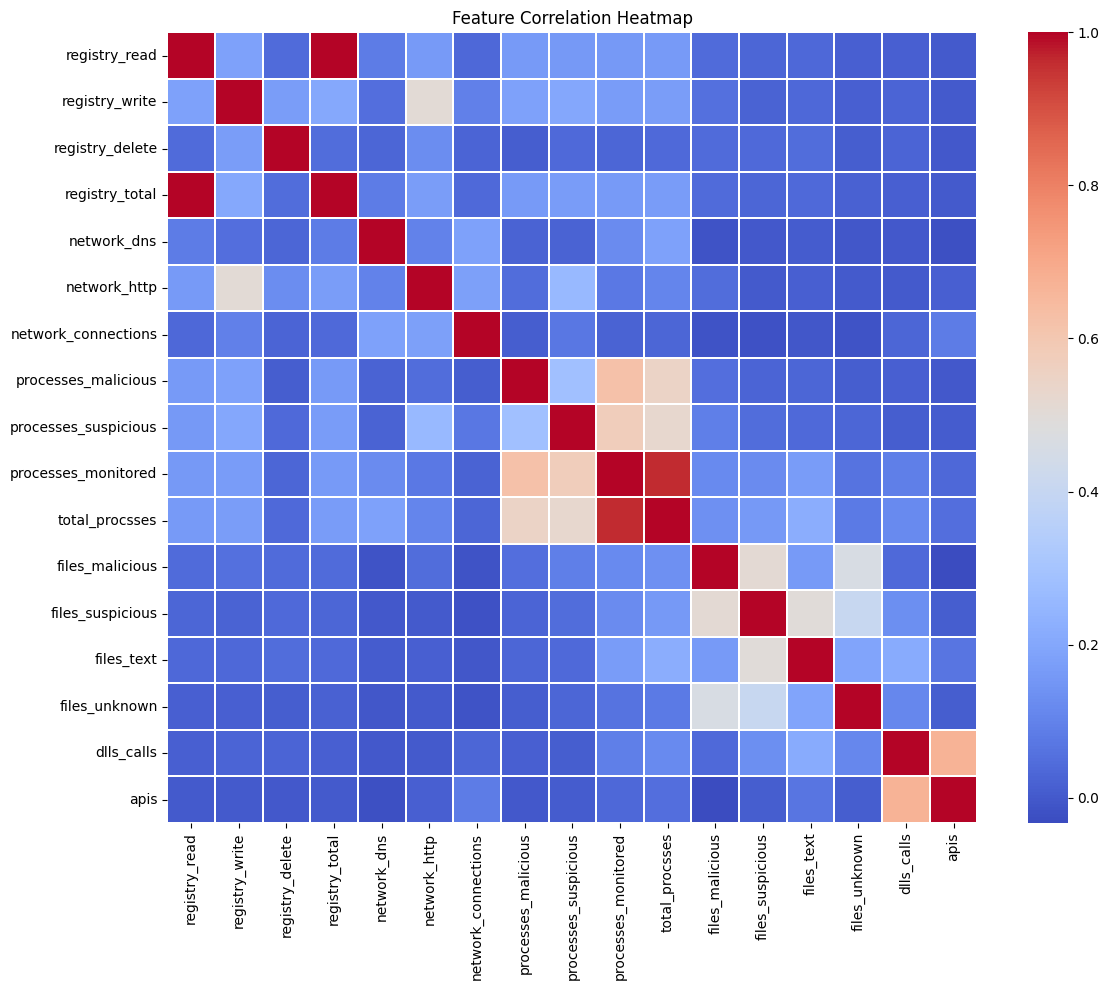

Saved correlation_heatmap.png


In [13]:
# =============================================================================
#  SECTION 2 — Feature Engineering & Scaling  (fit ONCE, reuse everywhere)
# =============================================================================
print("\n" + "="*70)
print("SECTION 2 — FEATURE ENGINEERING & SCALING")
print("="*70)

# Select numerical features only
df_numeric = df_malware.select_dtypes(include=[np.number]).copy()
print(f"Numerical features  : {df_numeric.shape[1]}")

# Remove zero-variance columns
vt = VarianceThreshold(threshold=0)
vt.fit(df_numeric)
df_numeric = df_numeric.iloc[:, vt.get_support()]
print(f"After VarianceThr.  : {df_numeric.shape[1]} features kept")

# Remove any all-null columns (safety)
df_numeric = df_numeric.dropna(axis=1, how='all')

# ── Single scaler instance — used everywhere downstream ──────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)          # numpy array, shape (n, p)
feature_names = df_numeric.columns.tolist()

print(f"Scaled array shape  : {X_scaled.shape}")
print(f"Feature names       : {feature_names}")

# Correlation heatmap
corr = df_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()
print("Saved correlation_heatmap.png")



SECTION 3 — UNSUPERVISED ANALYSIS


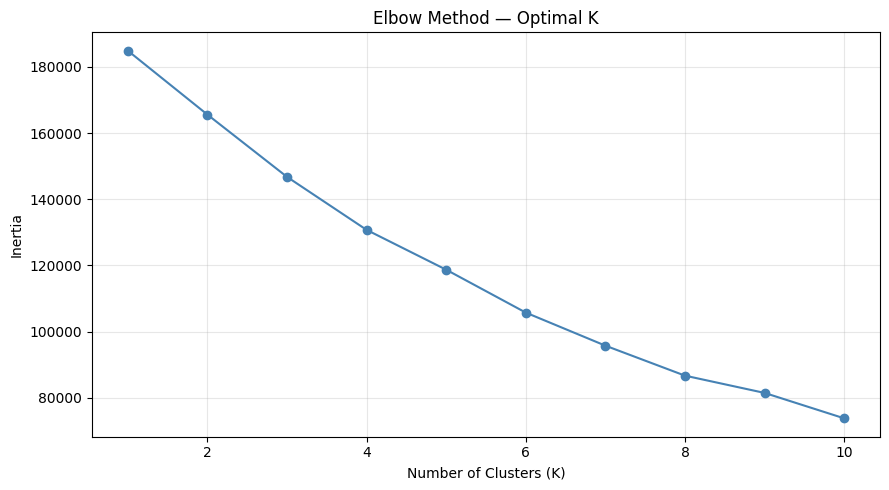

Saved elbow_curve.png

K-Means k=3  cluster distribution:
Cluster
0    10584
1      280
2       12


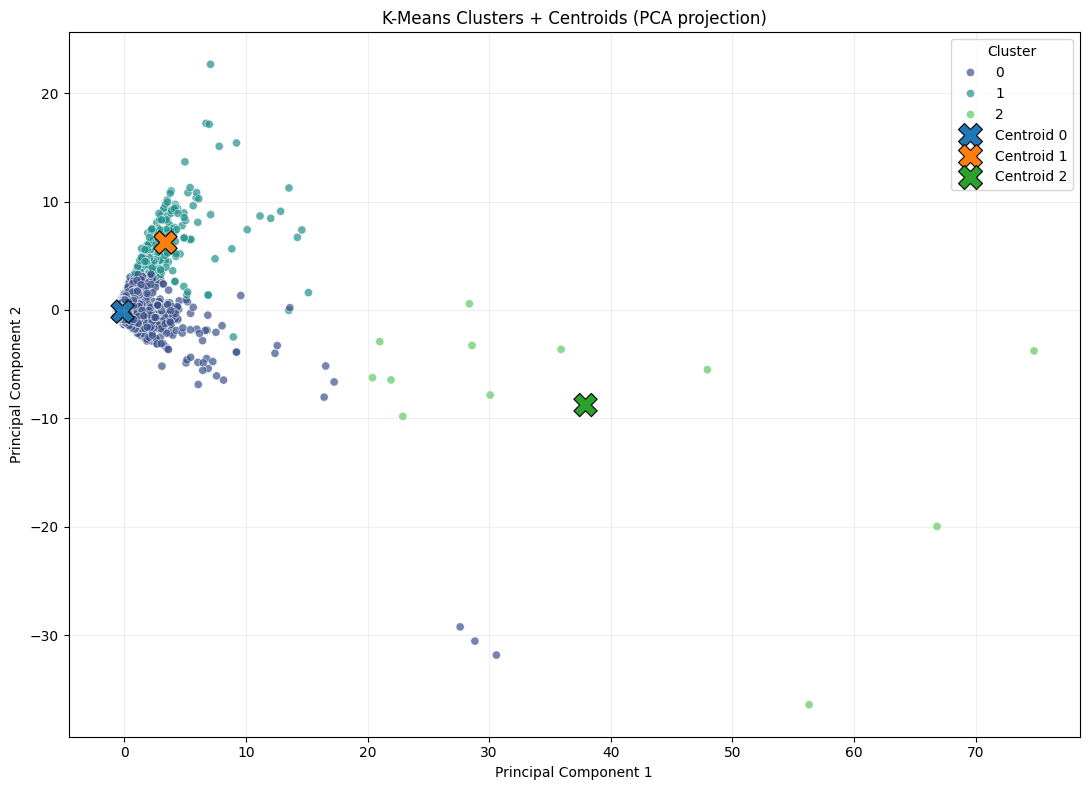

Saved pca_clusters.png

Cluster centroids (scaled feature values):
   registry_read  registry_write  registry_delete  registry_total  network_dns  network_http  network_connections  processes_malicious  processes_suspicious  processes_monitored  total_procsses  files_malicious  files_suspicious  files_text  files_unknown  dlls_calls      apis
0      -0.010692       -0.014604        -0.016834       -0.011025     0.000830     -0.009081             0.000828            -0.027682             -0.027652            -0.042505       -0.045938        -0.092282         -0.118184   -0.086676      -0.096052   -0.021844 -0.002785
1       0.171475        0.194704         0.592158        0.177460    -0.039396      0.026264            -0.080921             0.144343              0.198450             0.754423        0.932903         3.451316          4.477359    3.285350       3.637347    0.827053  0.107981
2       5.429424        8.337746         1.030812        5.583286     0.187501      7.396188       

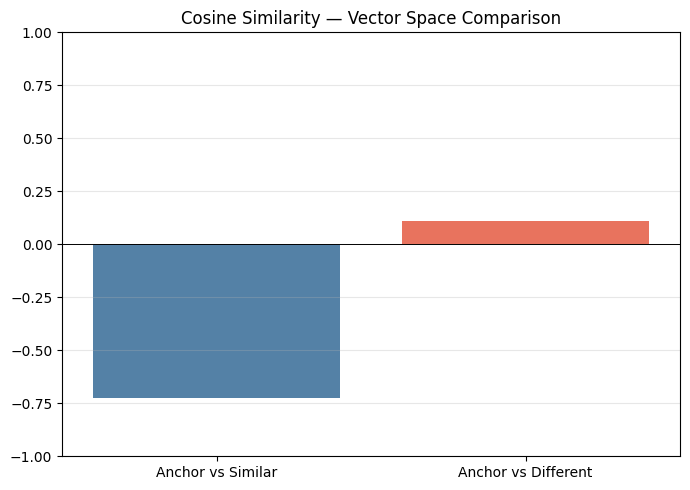

Saved cosine_similarity.png


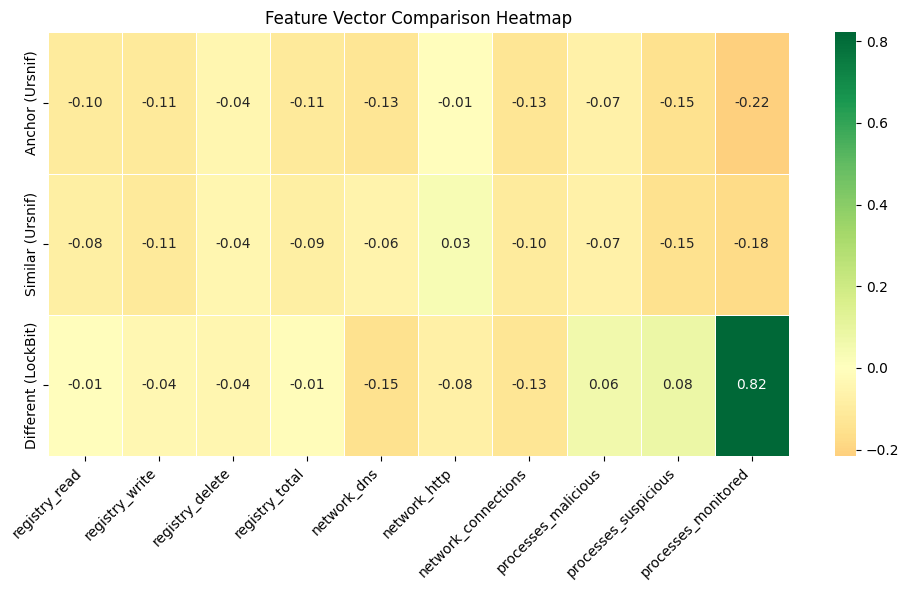

Saved vector_comparison_heatmap.png

Nearest neighbours of anchor sample (cosine distance):
  Rank 0: pos=7270  dist=0.0000  Family=Ursnif
  Rank 1: pos=7251  dist=0.0000  Family=Ursnif
  Rank 2: pos=7119  dist=0.0002  Family=Ursnif
  Rank 3: pos=7297  dist=0.0002  Family=Ursnif
  Rank 4: pos=7356  dist=0.0004  Family=Ursnif
  Rank 5: pos=7154  dist=0.0004  Family=Ursnif

Cleaned dataset saved → /content/drive/MyDrive/HyperShield/cleaned_ransomware.csv


In [14]:

# =============================================================================
#  SECTION 3 — Unsupervised Analysis: K-Means, PCA, Vector Space Model
# =============================================================================
print("\n" + "="*70)
print("SECTION 3 — UNSUPERVISED ANALYSIS")
print("="*70)

# ── 3a. Elbow Method (single loop, no duplicate) ─────────────────────────────
inertia = []
K_RANGE = range(1, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(K_RANGE), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'elbow_curve.png'), dpi=150)
plt.show()
print("Saved elbow_curve.png")

# ── 3b. K-Means with chosen optimal k ────────────────────────────────────────
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster as INTEGER (consistent type throughout)
df_malware['Cluster'] = cluster_labels.astype(int)

print(f"\nK-Means k={OPTIMAL_K}  cluster distribution:")
print(df_malware['Cluster'].value_counts().sort_index().to_string())

# ── 3c. PCA visualisation with centroids ─────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels.astype(str)          # string only for plot

# Project centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
df_centroids = pd.DataFrame(centroids_pca, columns=['PC1', 'PC2'])
df_centroids['Cluster'] = [f'Centroid {i}' for i in range(OPTIMAL_K)]

df_pca_all = pd.concat([df_pca, df_centroids], ignore_index=True)
sample_mask   = ~df_pca_all['Cluster'].str.startswith('Centroid')
centroid_mask =  df_pca_all['Cluster'].str.startswith('Centroid')

plt.figure(figsize=(11, 8))
sns.scatterplot(data=df_pca_all[sample_mask],
                x='PC1', y='PC2', hue='Cluster',
                palette='viridis', alpha=0.7, s=35, legend='full')
sns.scatterplot(data=df_pca_all[centroid_mask],
                x='PC1', y='PC2', hue='Cluster',
                palette='tab10', marker='X', s=280,
                edgecolor='black', linewidth=0.8, legend='full')
plt.title('K-Means Clusters + Centroids (PCA projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_clusters.png'), dpi=150)
plt.show()
print("Saved pca_clusters.png")

# ── 3d. Centroid profile / cross-tab ─────────────────────────────────────────
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)
print("\nCluster centroids (scaled feature values):")
print(centroid_df.to_string())

if 'Family' in df_malware.columns:
    cross_tab = pd.crosstab(df_malware['Family'], df_malware['Cluster'])
    print("\nFamily × Cluster cross-tabulation:")
    print(cross_tab.to_string())

# ── 3e. Euclidean distance — sample to centroid validation ───────────────────
print("\nSample-to-centroid Euclidean distances (5 random samples):")
random_pos_idx = np.random.RandomState(72).choice(len(X_scaled), 5, replace=False)

for pos in random_pos_idx:
    sample_vec = X_scaled[pos]
    orig_idx   = df_malware.index[pos]
    dists = [(f'Cluster {j}', euclidean(sample_vec, c))
             for j, c in enumerate(kmeans.cluster_centers_)]
    dists.sort(key=lambda x: x[1])
    print(f"\n  Sample pos={pos} | Family={df_malware.loc[orig_idx, 'Family'] if 'Family' in df_malware.columns else 'N/A'}"
          f" | Assigned={df_malware.loc[orig_idx, 'Cluster']}")
    for name, d in dists:
        print(f"    {name}: {d:.4f}")

# ── 3f. Cosine Similarity — Vector Space Model ───────────────────────────────
print("\n--- Vector Space Model (Cosine Similarity) ---")

# Anchor: random sample
anchor_pos    = np.random.RandomState(42).choice(len(X_scaled), 1)[0]
anchor_family = df_malware.iloc[anchor_pos]['Family'] if 'Family' in df_malware.columns else None
anchor_cluster = int(df_malware.iloc[anchor_pos]['Cluster'])

# Similar: same family, different position
if anchor_family:
    same_family_mask = (df_malware['Family'] == anchor_family).values
    same_family_mask[anchor_pos] = False
    cands = np.where(same_family_mask)[0]
else:
    cands = np.array([i for i in range(len(X_scaled)) if i != anchor_pos])

similar_pos = cands[np.random.RandomState(42).choice(len(cands), 1)[0]] if len(cands) else anchor_pos

# Different: different cluster
diff_mask = df_malware['Cluster'].values != anchor_cluster
diff_cands = np.where(diff_mask)[0]
different_pos = diff_cands[np.random.RandomState(42).choice(len(diff_cands), 1)[0]]

# Scores
sim_score  = cosine_similarity(X_scaled[anchor_pos].reshape(1, -1),
                               X_scaled[similar_pos].reshape(1, -1))[0][0]
diff_score = cosine_similarity(X_scaled[anchor_pos].reshape(1, -1),
                               X_scaled[different_pos].reshape(1, -1))[0][0]

print(f"Anchor   : pos={anchor_pos}  | Family={anchor_family}  | Cluster={anchor_cluster}")
print(f"Similar  : pos={similar_pos} | Family={df_malware.iloc[similar_pos].get('Family','N/A')}")
print(f"Different: pos={different_pos} | Family={df_malware.iloc[different_pos].get('Family','N/A')}")
print(f"\nCosine Similarity (Anchor vs Similar)   : {sim_score:.4f}")
print(f"Cosine Similarity (Anchor vs Different) : {diff_score:.4f}")

# Bar chart
plt.figure(figsize=(7, 5))
sns.barplot(
    x=['Anchor vs Similar', 'Anchor vs Different'],
    y=[sim_score, diff_score],
    palette=['steelblue', 'tomato']
)
plt.title('Cosine Similarity — Vector Space Comparison')
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.7)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cosine_similarity.png'), dpi=150)
plt.show()
print("Saved cosine_similarity.png")

# Feature vector heatmap (top N features for readability)
TOP_N = min(10, len(feature_names))
comparison_df = pd.DataFrame(
    {
        f'Anchor ({anchor_family or "Sample"})':   X_scaled[anchor_pos, :TOP_N],
        f'Similar ({df_malware.iloc[similar_pos].get("Family", "S") if "Family" in df_malware.columns else "Similar"})':
                                                    X_scaled[similar_pos, :TOP_N],
        f'Different ({df_malware.iloc[different_pos].get("Family", "D") if "Family" in df_malware.columns else "Diff"})':
                                                    X_scaled[different_pos, :TOP_N],
    },
    index=feature_names[:TOP_N]
)
plt.figure(figsize=(10, 6))
sns.heatmap(comparison_df.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.4)
plt.title('Feature Vector Comparison Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vector_comparison_heatmap.png'), dpi=150)
plt.show()
print("Saved vector_comparison_heatmap.png")

# Nearest Neighbours (cosine)
nn = NearestNeighbors(n_neighbors=6, metric='cosine')
nn.fit(X_scaled)
distances, indices = nn.kneighbors(X_scaled[anchor_pos].reshape(1, -1))
print("\nNearest neighbours of anchor sample (cosine distance):")
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0])):
    fam = df_malware.iloc[idx].get('Family', 'N/A') if 'Family' in df_malware.columns else 'N/A'
    print(f"  Rank {rank}: pos={idx}  dist={dist:.4f}  Family={fam}")

# ── Save intermediate cleaned dataset ────────────────────────────────────────
CLEANED_CSV = os.path.join(OUTPUT_DIR, 'cleaned_ransomware.csv')
df_malware.to_csv(CLEANED_CSV, index=False)
print(f"\nCleaned dataset saved → {CLEANED_CSV}")



SECTION 4 — SUPERVISED CLASSIFICATION
Target classes (26): ['Agenttesla' 'Cerber' 'DarkSide' 'Dharma' 'Emotet' 'Formbook' 'Gandcrab'
 'Gh0st' 'Glupteba' 'Guloader' 'LockBit' 'Maze' 'NanoCore' 'Phobos' 'Qbot'
 'REvil' 'Raccoon' 'Ragnar' 'RedLine' 'Remcos' 'Ryuk' 'Shade' 'Snake'
 'Ursnif' 'WannaCry' 'njRat']

[*] Training Random Forest...

Random Forest — Classification Report:
              precision    recall  f1-score   support

  Agenttesla       0.94      0.97      0.96        67
      Cerber       0.93      0.98      0.96        66
    DarkSide       0.99      0.99      0.99        67
      Dharma       0.98      0.97      0.98       101
      Emotet       0.94      0.94      0.94        69
    Formbook       0.97      0.96      0.96        95
    Gandcrab       0.97      0.95      0.96        76
       Gh0st       0.88      0.85      0.86        91
    Glupteba       0.93      0.94      0.94        69
    Guloader       0.93      0.94      0.94        89
     LockBit       0.99  

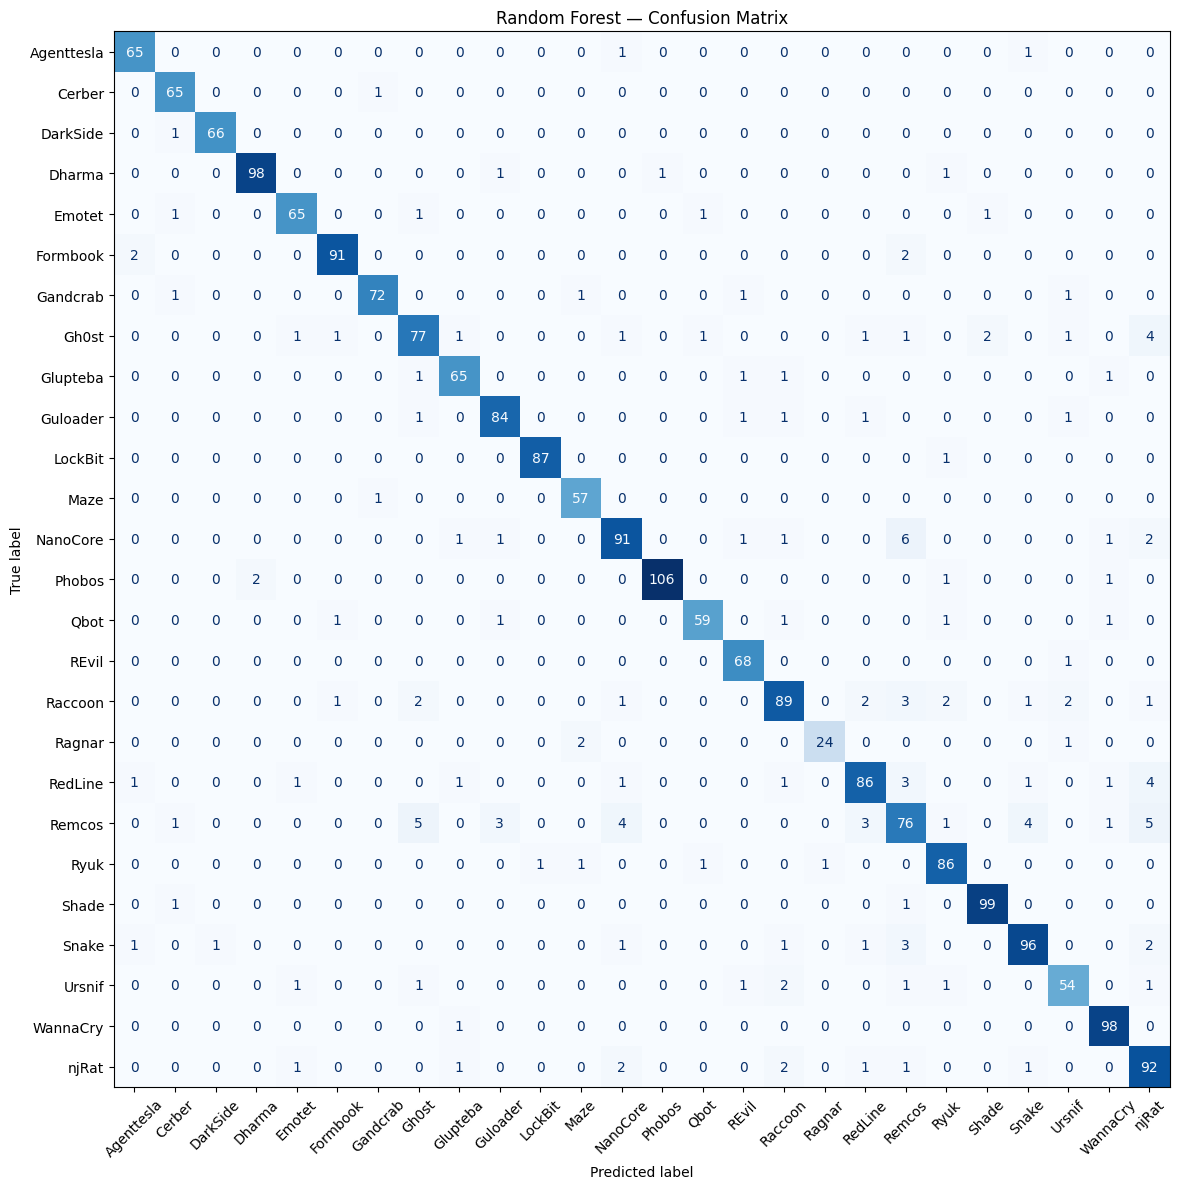

Saved rf_confusion_matrix.png


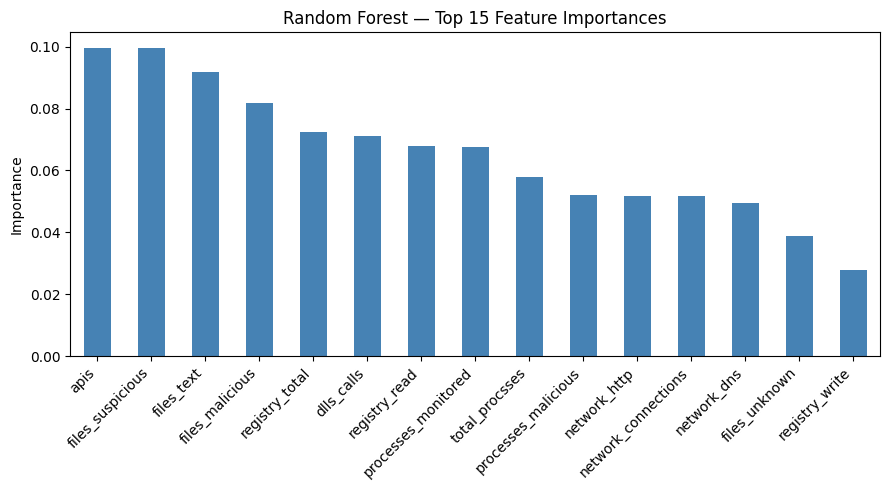

Saved rf_feature_importance.png

[*] Training XGBoost...

XGBoost — Classification Report:
              precision    recall  f1-score   support

  Agenttesla       0.93      0.99      0.96        67
      Cerber       0.93      1.00      0.96        66
    DarkSide       1.00      0.99      0.99        67
      Dharma       0.98      0.98      0.98       101
      Emotet       0.98      0.91      0.95        69
    Formbook       0.95      0.95      0.95        95
    Gandcrab       0.97      0.96      0.97        76
       Gh0st       0.91      0.92      0.92        91
    Glupteba       0.96      0.96      0.96        69
    Guloader       0.92      0.96      0.94        89
     LockBit       0.98      0.95      0.97        88
        Maze       0.92      0.95      0.93        58
    NanoCore       0.90      0.88      0.89       104
      Phobos       0.99      0.98      0.99       110
        Qbot       0.92      0.92      0.92        64
       REvil       0.94      0.99      0.96 

In [15]:
# =============================================================================
#  SECTION 4 — Supervised Classification: Random Forest + XGBoost
# =============================================================================
print("\n" + "="*70)
print("SECTION 4 — SUPERVISED CLASSIFICATION")
print("="*70)

if 'Family' not in df_malware.columns:
    print("No 'Family' column found — skipping supervised section.")
else:
    le = LabelEncoder()
    y  = le.fit_transform(df_malware['Family'])
    n_classes = len(le.classes_)
    print(f"Target classes ({n_classes}): {le.classes_}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    # Sample weights for imbalanced multi-class (works for both RF and XGBoost)
    sample_weights_train = compute_sample_weight('balanced', y_train)

    # ── 4a. Random Forest ────────────────────────────────────────────────────
    print("\n[*] Training Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',    # handled internally by RF
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    print("\nRandom Forest — Classification Report:")
    print(classification_report(y_test, pred_rf, target_names=le.classes_))

    rf_roc = roc_auc_score(y_test, rf.predict_proba(X_test),
                           multi_class='ovr', average='weighted')
    print(f"RF  Weighted ROC-AUC : {rf_roc:.4f}")

    # Confusion matrix
    cm_rf = confusion_matrix(y_test, pred_rf)
    disp  = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                   display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(14, 12))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
    ax.set_title('Random Forest — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'rf_confusion_matrix.png'), dpi=150)
    plt.show()
    print("Saved rf_confusion_matrix.png")

    # Feature importance
    feat_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    feat_imp.head(15).plot(kind='bar', color='steelblue')
    plt.title('Random Forest — Top 15 Feature Importances')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'rf_feature_importance.png'), dpi=150)
    plt.show()
    print("Saved rf_feature_importance.png")

    # ── 4b. XGBoost (multi-class fix) ────────────────────────────────────────
    print("\n[*] Training XGBoost...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        use_label_encoder=False,        # suppress deprecation warning
        eval_metric='mlogloss',         # correct metric for multi-class
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    # Pass sample_weight to handle class imbalance properly in multi-class
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    pred_xgb = xgb_model.predict(X_test)

    print("\nXGBoost — Classification Report:")
    print(classification_report(y_test, pred_xgb, target_names=le.classes_))

    xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(X_test),
                             multi_class='ovr', average='weighted')
    print(f"XGB Weighted ROC-AUC : {xgb_roc:.4f}")

    # ── 4c. Benchmark summary ─────────────────────────────────────────────────
    print("\n" + "-"*40)
    print("MODEL BENCHMARK SUMMARY")
    print("-"*40)
    print(f"{'Model':<20} {'ROC-AUC':>10}")
    print(f"{'Random Forest':<20} {rf_roc:>10.4f}")
    print(f"{'XGBoost':<20} {xgb_roc:>10.4f}")


In [16]:
# =============================================================================
#  SECTION 5 — Ensemble Anomaly Detection (RobustThreatHuntingModule class)
# =============================================================================
print("\n" + "="*70)
print("SECTION 5 — ENSEMBLE ANOMALY DETECTION ENGINE (CLASS DEFINITION)")
print("="*70)


class RobustThreatHuntingModule:
    """
    6-model ensemble anomaly detection pipeline.

    Models:
      Classical : Isolation Forest, KNN, ECOD, LOF, HBOS
      Deep      : DeepSVDD (optional — requires torch)

    Usage:
        hunter   = RobustThreatHuntingModule(contamination_rate=0.03)
        anomalies = hunter.hunt(X_scaled, df_malware, feature_names)
    """

    def __init__(self,
                 contamination_rate: float = 0.03,
                 ensemble_method: str = 'average',
                 use_deep_svdd: bool = True,
                 deep_svdd_epochs: int = 60,
                 deep_svdd_hidden_neurons: list = None,
                 random_state: int = 42,
                 verbose: bool = True):

        self.contamination_rate        = contamination_rate
        self.ensemble_method           = ensemble_method
        self.use_deep_svdd             = use_deep_svdd
        self.deep_svdd_epochs          = deep_svdd_epochs
        self.deep_svdd_hidden_neurons  = deep_svdd_hidden_neurons or [128, 64, 32]
        self.random_state              = random_state          # ← FIX: use arg, not hardcoded 42
        self.verbose                   = verbose

        self.classifiers      = None
        self.ensemble_scores  = None
        self.results_df       = None
        self.anomalies        = None

    def _build_ensemble(self, n_features: int):
        """Construct the detector ensemble."""
        self.classifiers = {
            'Isolation Forest': IForest(
                contamination=self.contamination_rate,
                random_state=self.random_state,
                n_estimators=200
            ),
            'KNN': KNN(
                contamination=self.contamination_rate,
                n_neighbors=min(20, n_features)
            ),
            'ECOD': ECOD(contamination=self.contamination_rate),
            'LOF':  LOF(
                contamination=self.contamination_rate,
                n_neighbors=min(20, n_features)
            ),
            'HBOS': HBOS(
                contamination=self.contamination_rate,
                n_bins=20
            ),
        }

        if self.use_deep_svdd:
            try:
                from pyod.models.deep_svdd import DeepSVDD
                self.classifiers['DeepSVDD'] = DeepSVDD(
                    n_features=n_features,
                    contamination=self.contamination_rate,
                    hidden_neurons=self.deep_svdd_hidden_neurons,
                    epochs=self.deep_svdd_epochs,
                    batch_size=32,
                    random_state=self.random_state,
                    verbose=0
                )
                if self.verbose:
                    print("    [DeepSVDD] Loaded successfully.")
            except (ImportError, Exception) as e:
                if self.verbose:
                    print(f"    [DeepSVDD] Unavailable ({e}). Running 5-model ensemble.")

    def _shap_root_cause(self, X_scaled: np.ndarray, top_row_pos: int):
        """Run SHAP TreeExplainer on Isolation Forest for the top anomaly."""
        iforest_wrapper = self.classifiers.get('Isolation Forest')
        if iforest_wrapper is None:
            return

        # → FIX: access the underlying sklearn estimator via .detector_ ←
        try:
            sklearn_iforest = iforest_wrapper.detector_
        except AttributeError:
            sklearn_iforest = iforest_wrapper  # fallback for older PyOD versions

        try:
            explainer  = shap.TreeExplainer(sklearn_iforest)
            top_vector = X_scaled[top_row_pos].reshape(1, -1)
            shap_vals  = explainer.shap_values(top_vector)

            shap_df = pd.DataFrame({
                'Feature':     feature_names,
                'SHAP_Impact': shap_vals[0],
                'Scaled_Value': top_vector[0]
            })
            shap_df['|Impact|'] = shap_df['SHAP_Impact'].abs()
            shap_df = shap_df.sort_values('|Impact|', ascending=False).drop(columns='|Impact|')

            print("\nTop 5 features driving the anomaly alert:")
            print(shap_df.head(5).to_string(index=False))

            # Force plot
            try:
                shap.initjs()
                shap.force_plot(
                    explainer.expected_value,
                    shap_vals[0],
                    top_vector[0],
                    feature_names=feature_names,
                    matplotlib=True
                )
                plt.show()
            except Exception:
                print("   (Force plot skipped — works best in Colab/Jupyter)")

        except Exception as e:
            print(f"   [SHAP] Could not run explanation: {e}")

    def hunt(self, X_scaled: np.ndarray,
             original_df: pd.DataFrame,
             feature_names: list) -> pd.DataFrame:
        """
        Run the full threat hunting pipeline.
        Returns a DataFrame of detected anomalies sorted by severity.
        """
        n_samples, n_features = X_scaled.shape

        if self.classifiers is None:
            self._build_ensemble(n_features=n_features)

        n_models = len(self.classifiers)
        print(f"\n{'='*80}")
        print("ROBUST THREAT HUNTING MODULE")
        print(f"Samples            : {n_samples}")
        print(f"Features           : {n_features}")
        print(f"Models in ensemble : {n_models}")
        print(f"Contamination rate : {self.contamination_rate*100:.2f}%")
        print(f"Ensemble method    : {self.ensemble_method.upper()}")
        print(f"{'='*80}\n")

        # → 1. Train all detectors ←
        train_scores = np.zeros((n_samples, n_models))

        for i, (name, clf) in enumerate(self.classifiers.items()):
            print(f"  Training {name:<22}...", end=' ', flush=True)
            try:
                clf.fit(X_scaled)
                train_scores[:, i] = clf.decision_scores_
                flagged = int(np.sum(clf.labels_ == 1)) if hasattr(clf, 'labels_') else 'N/A'
                print(f"done  (internal flags: {flagged})")
            except Exception as e:
                print(f"FAILED — {e}  (zeroing out column)")

        # → 2. Normalise + ensemble ←
        print("\n  Standardising scores (PyOD utility)...")
        standardized_scores = standardizer(train_scores)

        if self.ensemble_method == 'average':
            self.ensemble_scores = standardized_scores.mean(axis=1)
        elif self.ensemble_method == 'maximum':
            self.ensemble_scores = standardized_scores.max(axis=1)
        else:
            raise ValueError("ensemble_method must be 'average' or 'maximum'")

        # Enforce contamination threshold exactly
        threshold = np.percentile(self.ensemble_scores,
                                  100 * (1 - self.contamination_rate))
        ensemble_labels = (self.ensemble_scores > threshold).astype(int)
        n_anomalies = int(ensemble_labels.sum())

        print(f"\n  SCAN COMPLETE — {n_anomalies} high-confidence anomalies detected "
              f"({self.contamination_rate*100:.1f}% contamination rate enforced)")

        # → 3. Score distribution plot ←
        plt.figure(figsize=(13, 5))
        sns.histplot(self.ensemble_scores, bins=100, kde=True,
                     color='darkviolet', alpha=0.7)
        plt.axvline(threshold, color='red', linestyle='--', linewidth=2.5,
                    label=f'Threshold ({self.contamination_rate*100:.1f}%)')
        plt.title(f'Ensemble Anomaly Score Distribution ({n_models}-model ensemble)',
                  fontsize=14, fontweight='bold')
        plt.xlabel('Normalised Ensemble Score  (higher = more anomalous)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'anomaly_score_distribution.png'), dpi=150)
        plt.show()
        print("Saved anomaly_score_distribution.png")

        if n_anomalies == 0:
            print("\n  No significant anomalies detected at this contamination level.")
            return None

        # → 4. Build results DataFrame ←
        self.results_df = original_df.copy().reset_index(drop=True)
        self.results_df['Ensemble_Anomaly_Score'] = self.ensemble_scores
        self.results_df['Is_Anomaly']             = ensemble_labels

        self.anomalies = (self.results_df[self.results_df['Is_Anomaly'] == 1]
                          .sort_values('Ensemble_Anomaly_Score', ascending=False))

        display_cols = [c for c in ['Family', 'Cluster', 'Ensemble_Anomaly_Score']
                        if c in self.anomalies.columns]
        print("\n--- TOP 10 MOST SEVERE ANOMALIES ---")
        print(self.anomalies[display_cols].head(10).to_string(index=False))

        # → 5. SHAP root-cause on the single most severe anomaly ←
        top_row_pos = self.anomalies.index[0]   # positional index in reset_index df
        top_family  = (self.results_df.loc[top_row_pos, 'Family']
                       if 'Family' in self.results_df.columns else 'N/A')

        print(f"\nROOT CAUSE ANALYSIS — most severe sample "
              f"(pos={top_row_pos}, Family={top_family})")
        self._shap_root_cause(X_scaled, top_row_pos)

        # → 6. Anomaly cluster breakdown ←
        if 'Cluster' in self.anomalies.columns:
            print("\nAnomalies per cluster:")
            print(self.anomalies['Cluster'].value_counts().to_string())

        if 'Family' in self.anomalies.columns:
            print("\nAnomalies per family (top 10):")
            print(self.anomalies['Family'].value_counts().head(10).to_string())

        return self.anomalies



SECTION 5 — ENSEMBLE ANOMALY DETECTION ENGINE (CLASS DEFINITION)


    [DeepSVDD] Loaded successfully.

ROBUST THREAT HUNTING MODULE
Samples            : 10876
Features           : 17
Models in ensemble : 6
Contamination rate : 3.00%
Ensemble method    : AVERAGE

  Training Isolation Forest      ... done  (internal flags: 327)
  Training KNN                   ... done  (internal flags: 327)
  Training ECOD                  ... done  (internal flags: 327)
  Training LOF                   ... done  (internal flags: 327)
  Training HBOS                  ... done  (internal flags: 327)
  Training DeepSVDD              ... Epoch 1/60, Loss: 34.804016658104956
Epoch 2/60, Loss: 32.896759279072285
Epoch 3/60, Loss: 34.42033378966153
Epoch 4/60, Loss: 33.72273454070091
Epoch 5/60, Loss: 35.56389670167118
Epoch 6/60, Loss: 34.953090275637805
Epoch 7/60, Loss: 35.15234314650297
Epoch 8/60, Loss: 35.27903877943754
Epoch 9/60, Loss: 35.74210248794407
Epoch 10/60, Loss: 36.18319530785084
Epoch 11/60, Loss: 32.12069958914071
Epoch 12/60, Loss: 36.87360287923366
Epo

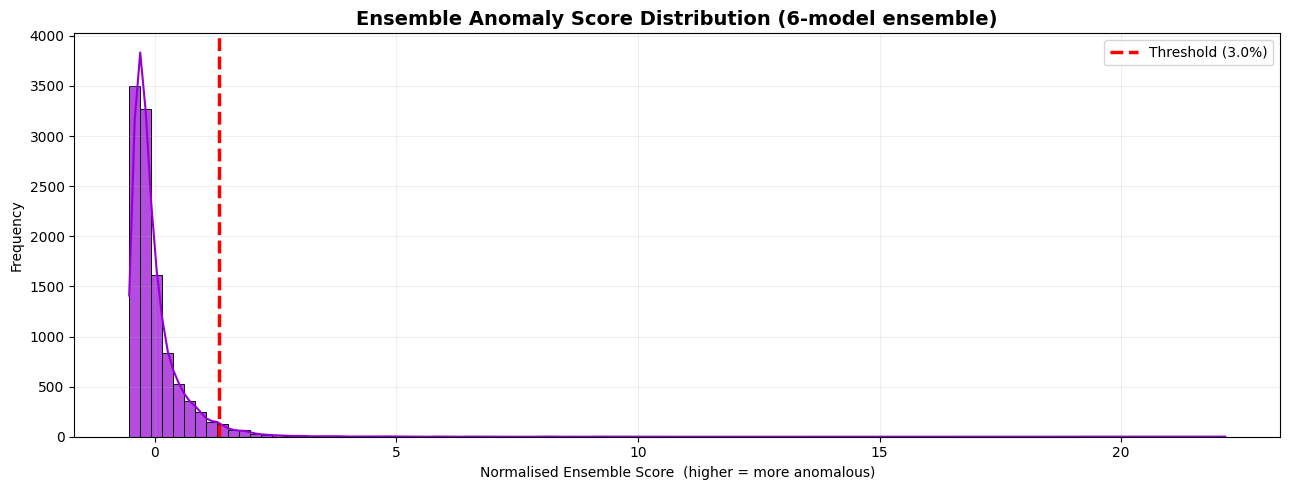

Saved anomaly_score_distribution.png

--- TOP 10 MOST SEVERE ANOMALIES ---
  Family  Cluster  Ensemble_Anomaly_Score
 Raccoon        2               22.151343
   njRat        1               15.975480
 Raccoon        2               11.747661
NanoCore        2               11.480045
Gandcrab        0               10.403013
  Ragnar        0                9.224103
   Snake        2                8.987541
  Ragnar        0                8.528997
  Ragnar        0                8.100568
  Remcos        0                8.092055

ROOT CAUSE ANALYSIS — most severe sample (pos=9724, Family=Raccoon)

Top 5 features driving the anomaly alert:
            Feature  SHAP_Impact  Scaled_Value
    registry_delete    -1.484257     12.791866
     registry_total    -1.381070     17.458683
network_connections    -1.347442     13.946437
     registry_write    -1.343331     61.401010
       network_http    -1.211605     86.488440


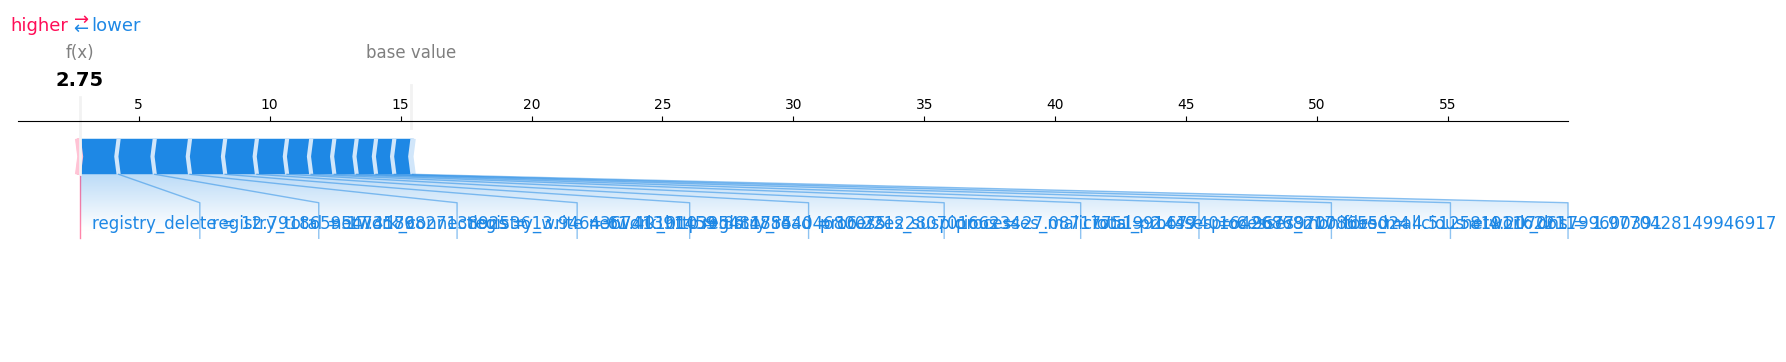


Anomalies per cluster:
Cluster
0    170
1    145
2     12

Anomalies per family (top 10):
Family
LockBit     92
Dharma      36
Ryuk        25
WannaCry    25
REvil       24
Phobos      20
Raccoon     19
Gandcrab    14
njRat       13
NanoCore     9

Anomaly results saved → /content/drive/MyDrive/HyperShield/detected_anomalies.csv


In [17]:
# =============================================================================
#  SECTION 5 — Ensemble Anomaly Detection (Execution)
# =============================================================================

# → FIX: reset_index ensures positional (0-based) integer index ←
#         so numpy array row positions align with df row positions exactly
df_for_hunter = df_malware.reset_index(drop=True)

hunter = RobustThreatHuntingModule(
    contamination_rate=0.03,
    ensemble_method='average',           # change to 'maximum' for zero-day focus
    use_deep_svdd=True,
    deep_svdd_epochs=60,
    deep_svdd_hidden_neurons=[128, 64, 32],
    random_state=RANDOM_STATE,
    verbose=True
)

detected_anomalies = hunter.hunt(
    X_scaled=X_scaled,                   # ← same scaler used in Section 2
    original_df=df_for_hunter,
    feature_names=feature_names
)

# → Save anomaly results ←
if detected_anomalies is not None:
    out_path = os.path.join(OUTPUT_DIR, 'detected_anomalies.csv')
    detected_anomalies.to_csv(out_path, index=False)
    print(f"\nAnomaly results saved → {out_path}")


In [18]:
# =============================================================================
#  SECTION 6 — Pipeline Summary
# =============================================================================
print("\n" + "="*70)
print("PIPELINE COMPLETE — SUMMARY")
print("="*70)
print(f"  Raw samples loaded          : {df_raw.shape[0]}")
print(f"  Malware samples analysed    : {df_malware.shape[0]}")
print(f"  Features used               : {len(feature_names)}")
print(f"  K-Means clusters            : {OPTIMAL_K}")
if 'Family' in df_malware.columns and 'rf_roc' in dir():
    print(f"  RF  ROC-AUC (family clf)    : {rf_roc:.4f}")
    print(f"  XGB ROC-AUC (family clf)    : {xgb_roc:.4f}")
n_detected = len(detected_anomalies) if detected_anomalies is not None else 0
print(f"  Anomalies flagged           : {n_detected}")
print(f"  All outputs saved to        : {OUTPUT_DIR}")
print("="*70)



PIPELINE COMPLETE — SUMMARY
  Raw samples loaded          : 21752
  Malware samples analysed    : 10876
  Features used               : 17
  K-Means clusters            : 3
  RF  ROC-AUC (family clf)    : 0.9960
  XGB ROC-AUC (family clf)    : 0.9973
  Anomalies flagged           : 327
  All outputs saved to        : /content/drive/MyDrive/HyperShield/



SECTION 7 — SYNTHETIC ZERO-DAY THREAT GENERATOR

Running Strategy 1 — GaussianMorph...

[Strategy 1] GaussianMorph — noise mutation of anomaly seeds
  Seeds: top 50 anomalies from hunt results

  ┌─ GaussianMorph (σ×0.25) (n=200)
  │   Isolation Forest        ██████████████████████           76.0%  (152/200)
  │   KNN                     ████████████████████████         81.0%  (162/200)
  │   ECOD                    ██████████████████████████████  100.0%  (200/200)
  │   LOF                     █████                            17.5%  (35/200)
  │   HBOS                    ██████████████████████           74.5%  (149/200)
  │   DeepSVDD                ████████████                     42.5%  (85/200)
  └─ Ensemble: 2 flagged (1.0%)  ○ Evaded


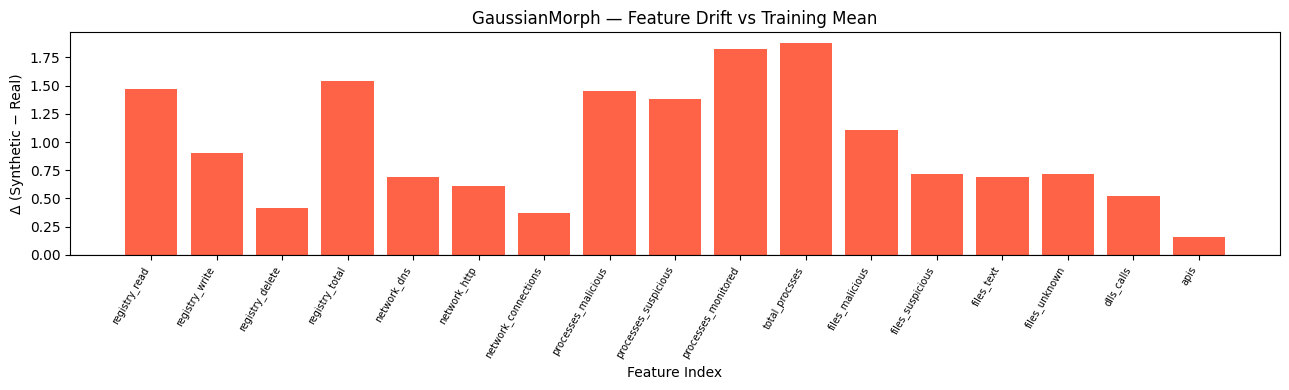

  Saved gen_gaussian_drift.png

Running Strategy 2 — CrossBreed...

[Strategy 2] CrossBreed — inter-family feature interpolation
  Generated 150 hybrid samples across 325 family pairs

  ┌─ CrossBreed (α∈(0.3, 0.7)) (n=150)
  │   Isolation Forest                                          1.3%  (2/150)
  │   KNN                                                       1.3%  (2/150)
  │   ECOD                    █                                 5.3%  (8/150)
  │   LOF                     █                                 3.3%  (5/150)
  │   HBOS                                                      2.7%  (4/150)
  │   DeepSVDD                                                  0.0%  (0/150)
  └─ Ensemble: 11 flagged (7.3%)  ○ Evaded


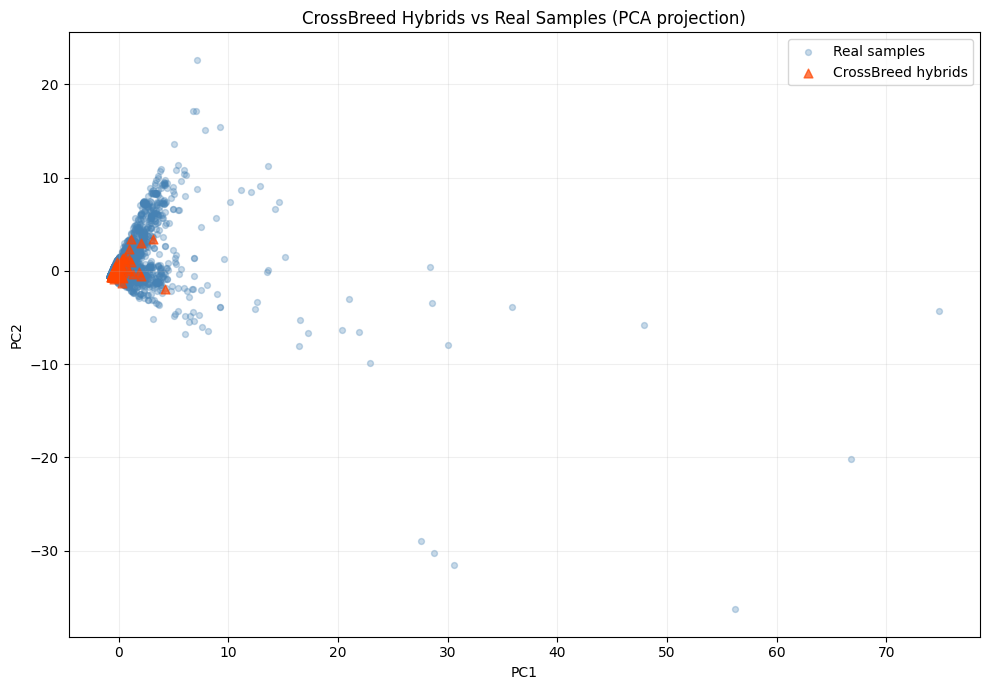

  Saved gen_crossbreed_pca.png

Running Strategy 3 — CentroidPush...

[Strategy 3] CentroidPush — out-of-distribution evasion samples
  Generated 150 out-of-distribution samples (push_strength=2.5σ)

  ┌─ CentroidPush (push=2.5σ) (n=150)
  │   Isolation Forest        ██                                6.7%  (10/150)
  │   KNN                     ███                              10.7%  (16/150)
  │   ECOD                    ██████████████████████████████  100.0%  (150/150)
  │   LOF                     ███████████████████              64.7%  (97/150)
  │   HBOS                    ███████                          24.7%  (37/150)
  │   DeepSVDD                                                  1.3%  (2/150)
  └─ Ensemble: 3 flagged (2.0%)  ○ Evaded


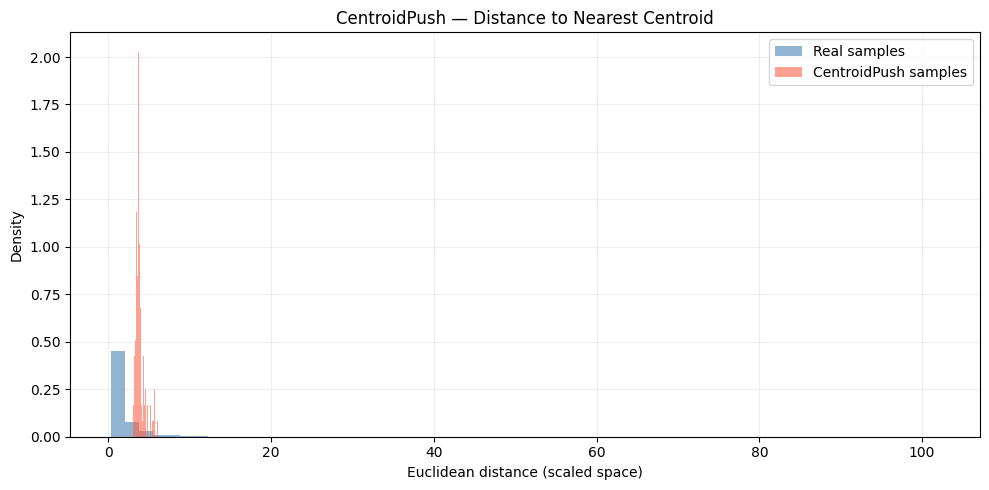

  Saved gen_centroid_push_dist.png

ZERO-DAY STRESS TEST — CONSOLIDATED SCORECARD
  Strategy                                  Samples   Flagged      Rate  Verdict
  ------------------------------------------------------------------
  GaussianMorph (σ×0.25)                        200         2      1.0%  🟢  LOW catch — evasion risk
  CrossBreed (α∈(0.3, 0.7))                     150        11      7.3%  🟢  LOW catch — evasion risk
  CentroidPush (push=2.5σ)                      150         3      2.0%  🟢  LOW catch — evasion risk


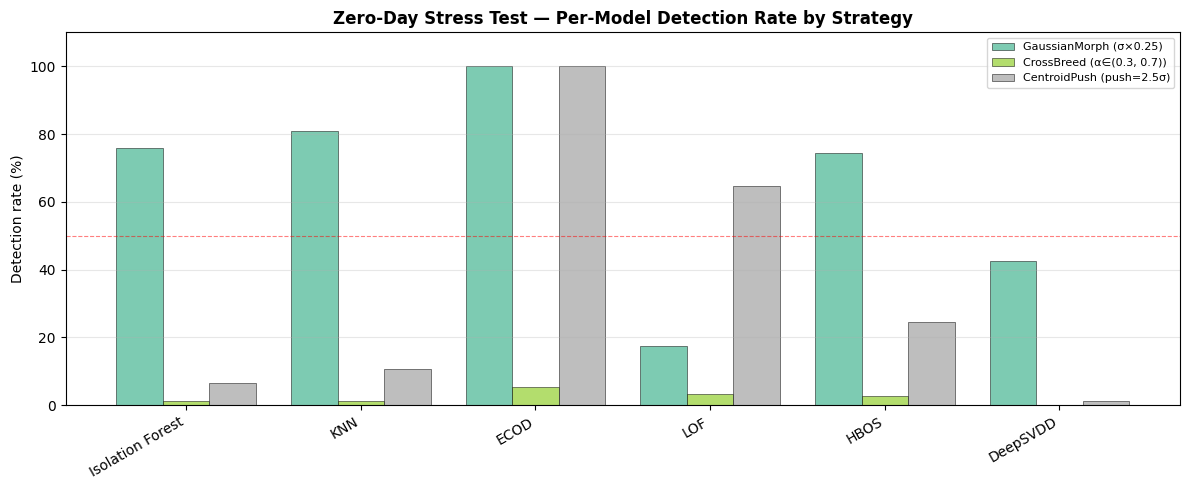

Saved zeroday_scorecard.png


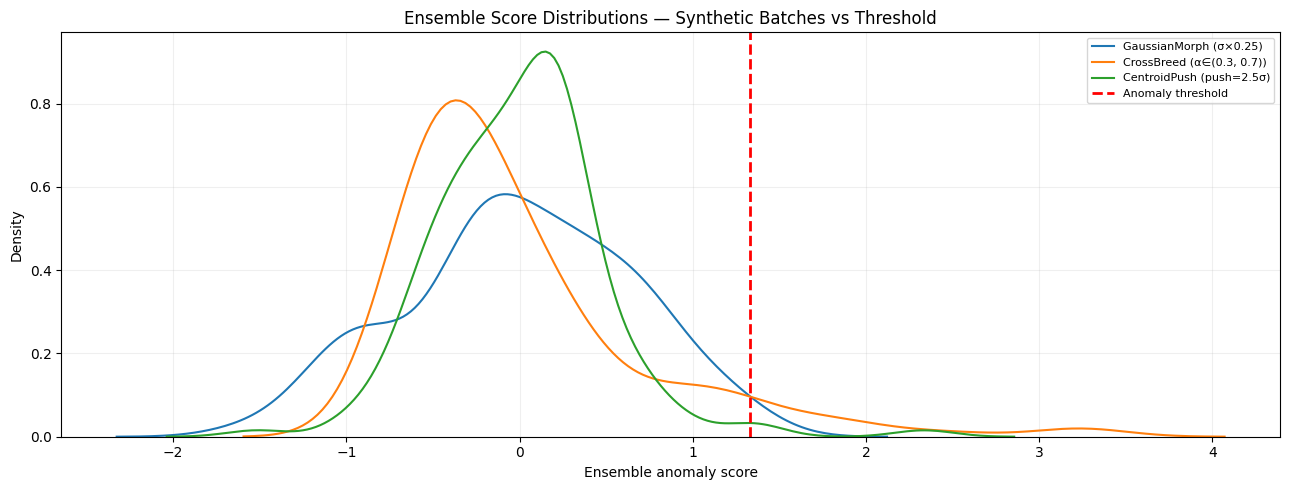

Saved zeroday_score_distributions.png

  All synthetic samples saved → /content/drive/MyDrive/HyperShield/synthetic_zeroday_samples.csv

--- Random Forest family prediction on synthetic samples ---

  GaussianMorph (σ×0.25)
  Predicted family distribution (top 5):
Dharma     45
LockBit    27
Raccoon    27
Ursnif     17
Phobos     14

  CrossBreed (α∈(0.3, 0.7))
  Predicted family distribution (top 5):
Ryuk        24
Gandcrab    16
REvil       11
Phobos      11
Maze        10

  CentroidPush (push=2.5σ)
  Predicted family distribution (top 5):
Guloader    41
Ursnif      14
REvil       10
RedLine     10
Gh0st        9

╔══════════════════════════════════════════════════════════════════════════╗
║            HOW TO READ THE ZERO-DAY STRESS TEST RESULTS                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Strategy            What it simulates                                   ║
║  ─────────────────   ─────────────────────────────────────────────

In [19]:
# =============================================================================
#  SECTION 7 — Synthetic Zero-Day Threat Generator & Zero-Day Stress Test
#
#  HOW IT PLUGS IN:
#    This block consumes the live pipeline objects produced by
#    hypershield_pipeline.py.  Append it to that file, OR run it in the next
#    cell of the same Colab notebook.  It needs exactly what the pipeline
#    already exposes:
#
#      X_scaled       – scaled feature matrix (numpy, n × p)
#      scaler         – the fitted StandardScaler (used to invert & re-scale)
#      feature_names  – list of feature column names
#      df_malware     – cleaned malware DataFrame with 'Family' & 'Cluster'
#      detected_anomalies – DataFrame returned by hunter.hunt()
#      kmeans         – fitted KMeans model
#      hunter         – RobustThreatHuntingModule (already trained)
#      rf             – fitted RandomForestClassifier (optional, for family clf)
#      le             – fitted LabelEncoder           (optional)
#      OUTPUT_DIR     – output directory string
#
#  THREE SYNTHESIS STRATEGIES are implemented:
#    1. GaussianMorph   – Gaussian noise injected around real anomaly seeds
#    2. CrossBreed      – feature interpolation between two different families
#    3. CentroidPush    – samples pushed away from cluster centroids by a
#                         random walk (maximally out-of-distribution)
#
#  ZERO-DAY EVALUATION:
#    All synthetic samples are fed through the TRAINED ensemble (no refit)
#    to measure how many the model flags WITHOUT having seen them.
# =============================================================================

import itertools

print("\n" + "="*70)
print("SECTION 7 — SYNTHETIC ZERO-DAY THREAT GENERATOR")
print("="*70)

# ─────────────────────────────────────────────────────────────────────────────
#  Guard: make sure upstream objects exist
# ─────────────────────────────────────────────────────────────────────────────
_required = {
    'X_scaled': 'scaled feature matrix',
    'scaler': 'StandardScaler',
    'feature_names': 'feature name list',
    'df_malware': 'cleaned malware DataFrame',
    'kmeans': 'fitted KMeans',
    'hunter': 'RobustThreatHuntingModule',
}
for _var, _desc in _required.items():
    assert _var in dir() or _var in vars(), \
        f"Missing '{_var}' ({_desc}). Run hypershield_pipeline.py first."

_has_rf  = 'rf' in dir() and 'le' in dir()
_has_ano = detected_anomalies is not None and len(detected_anomalies) > 0
n_features = X_scaled.shape[1]


# =============================================================================
#  7.1 — SyntheticThreatEngine
# =============================================================================

class SyntheticThreatEngine:
    """
    Generates synthetic malware behaviour vectors using three complementary
    strategies, then evaluates each batch through the live anomaly ensemble.

    Parameters
    ----------
    X_scaled        : numpy array (n, p) – already scaled real data
    scaler          : fitted StandardScaler – to invert for human-readable report
    feature_names   : list[str]
    df_malware      : DataFrame with 'Family', 'Cluster', 'Ensemble_Anomaly_Score'
    kmeans          : fitted KMeans (for CentroidPush strategy)
    hunter          : RobustThreatHuntingModule (trained ensemble inside)
    random_state    : int
    output_dir      : str
    """

    def __init__(self,
                 X_scaled,
                 scaler,
                 feature_names,
                 df_malware,
                 kmeans,
                 hunter,
                 random_state: int = 42,
                 output_dir: str = './'):

        self.X          = X_scaled
        self.scaler     = scaler
        self.features   = feature_names
        self.df         = df_malware.reset_index(drop=True)
        self.kmeans     = kmeans
        self.hunter     = hunter
        self.rng        = np.random.RandomState(random_state)
        self.out        = output_dir
        self.n_feat     = X_scaled.shape[1]

        # Pre-compute per-feature stats on training data for bounded generation
        self.feat_min   = X_scaled.min(axis=0)
        self.feat_max   = X_scaled.max(axis=0)
        self.feat_std   = X_scaled.std(axis=0)
        self.feat_mean  = X_scaled.mean(axis=0)

        # Store all generated batches for the final report
        self._all_batches: list[dict] = []

    # ── Utility ───────────────────────────────────────────────────────────────

    def _clip_to_range(self, X_gen: np.ndarray) -> np.ndarray:
        """Clip each feature to ±3 std from training mean (realistic range)."""
        lo = self.feat_mean - 3 * self.feat_std
        hi = self.feat_mean + 3 * self.feat_std
        return np.clip(X_gen, lo, hi)

    def _score_batch(self, X_batch: np.ndarray, label: str) -> dict:
        """
        Run a batch of synthetic samples through every trained detector
        in the ensemble WITHOUT re-fitting (inference only).

        Returns a dict with per-model and ensemble detection stats.
        """
        n = len(X_batch)
        model_flags = {}

        for name, clf in self.hunter.classifiers.items():
            if not hasattr(clf, 'decision_function'):
                # PyOD models expose predict() for inference
                try:
                    preds = clf.predict(X_batch)
                    flags = int(preds.sum())
                except Exception:
                    flags = -1
            else:
                try:
                    preds = clf.predict(X_batch)
                    flags = int(preds.sum())
                except Exception:
                    flags = -1
            model_flags[name] = flags

        # Ensemble score via average of normalised decision scores
        raw_scores = []
        for name, clf in self.hunter.classifiers.items():
            try:
                s = clf.decision_function(X_batch)
                raw_scores.append(s)
            except Exception:
                pass

        if raw_scores:
            stacked  = np.column_stack(raw_scores)          # (n, m)
            norm     = standardizer(stacked)
            ens_score = norm.mean(axis=1)
        else:
            ens_score = np.zeros(n)

        # Threshold: use same contamination % as original hunt
        thresh = np.percentile(self.hunter.ensemble_scores,
                               100 * (1 - self.hunter.contamination_rate))
        ens_flags = int((ens_score > thresh).sum())

        result = {
            'label':        label,
            'n_samples':    n,
            'model_flags':  model_flags,
            'ens_scores':   ens_score,
            'ens_flagged':  ens_flags,
            'ens_rate':     ens_flags / n,
            'X_batch':      X_batch,
        }
        self._all_batches.append(result)
        return result

    def _print_result(self, res: dict):
        n         = res['n_samples']
        rate      = res['ens_rate'] * 100
        ens_flags = res['ens_flagged']          # ← fix: read from res, not outer scope
        print(f"\n  ┌─ {res['label']} ({'n='}{n})")
        for name, flags in res['model_flags'].items():
            bar = '█' * int((flags / n) * 30) if flags >= 0 else '?'
            pct = f"{flags/n*100:5.1f}%" if flags >= 0 else "  N/A"
            print(f"  │   {name:<22}  {bar:<30}  {pct}  ({flags}/{n})")
        verdict = "⚠ ZERO-DAY ALERT" if rate >= 50 else ("◈ Partial detect" if rate >= 20 else "○ Evaded")
        print(f"  └─ Ensemble: {ens_flags} flagged ({rate:.1f}%)  {verdict}")

    # ── Strategy 1 — GaussianMorph ────────────────────────────────────────────

    def gaussian_morph(self,
                       n_samples: int = 200,
                       noise_std_factor: float = 0.25,
                       seed_from: str = 'anomalies') -> dict:
        """
        Inject calibrated Gaussian noise around seed vectors.

        seed_from : 'anomalies' – seeds are the detected anomalies (highest
                                  anomaly score → most extreme behaviour)
                    'all'       – seeds are random samples from X_scaled
        """
        print("\n[Strategy 1] GaussianMorph — noise mutation of anomaly seeds")

        if seed_from == 'anomalies' and _has_ano:
            seed_idx = detected_anomalies.index[:min(50, len(detected_anomalies))]
            seeds    = self.X[seed_idx]
            print(f"  Seeds: top {len(seed_idx)} anomalies from hunt results")
        else:
            chosen   = self.rng.choice(len(self.X), min(50, len(self.X)), replace=False)
            seeds    = self.X[chosen]
            print(f"  Seeds: {len(seeds)} random samples from full dataset")

        # Repeat seeds to reach n_samples
        repeats  = -(-n_samples // len(seeds))           # ceiling div
        base     = np.tile(seeds, (repeats, 1))[:n_samples]

        # Per-feature noise scaled by each feature's std
        noise    = self.rng.normal(0, noise_std_factor, base.shape) * self.feat_std
        X_morph  = self._clip_to_range(base + noise)

        res = self._score_batch(X_morph, f'GaussianMorph (σ×{noise_std_factor})')
        self._print_result(res)

        # Feature drift plot
        morph_mean = X_morph.mean(axis=0)
        real_mean  = self.X.mean(axis=0)
        drift      = morph_mean - real_mean

        plt.figure(figsize=(13, 4))
        plt.bar(range(self.n_feat), drift,
                color=['tomato' if d > 0 else 'steelblue' for d in drift])
        plt.axhline(0, color='black', linewidth=0.8)
        plt.title('GaussianMorph — Feature Drift vs Training Mean')
        plt.xlabel('Feature Index')
        plt.ylabel('Δ (Synthetic − Real)')
        plt.xticks(range(self.n_feat), self.features, rotation=60, ha='right',
                   fontsize=max(5, 9 - self.n_feat // 8))
        plt.tight_layout()
        plt.savefig(os.path.join(self.out, 'gen_gaussian_drift.png'), dpi=150)
        plt.show()
        print("  Saved gen_gaussian_drift.png")

        return res

    # ── Strategy 2 — CrossBreed ───────────────────────────────────────────────

    def cross_breed(self,
                    n_pairs: int = 100,
                    alpha_range: tuple = (0.3, 0.7)) -> dict:
        """
        Linear interpolation between feature vectors from two DIFFERENT families.
        Models what a mutant / hybrid ransomware strain might look like.

        α ∈ alpha_range controls the mixing weight (chosen randomly per pair).
        """
        print("\n[Strategy 2] CrossBreed — inter-family feature interpolation")

        if 'Family' not in self.df.columns:
            print("  No 'Family' column — falling back to inter-cluster breeding.")
            group_col = 'Cluster'
        else:
            group_col = 'Family'

        groups  = self.df[group_col].unique()
        pairs   = list(itertools.combinations(groups, 2))
        if len(pairs) == 0:
            print("  Not enough distinct groups for cross-breeding. Skipping.")
            return {}

        # Sample pairs (with replacement if needed)
        chosen_pairs = [pairs[i % len(pairs)]
                        for i in self.rng.choice(len(pairs), n_pairs)]

        hybrids = []
        for g1, g2 in chosen_pairs:
            idx1 = self.df[self.df[group_col] == g1].index.tolist()
            idx2 = self.df[self.df[group_col] == g2].index.tolist()
            if not idx1 or not idx2:
                continue
            r1   = self.X[self.rng.choice(idx1)]
            r2   = self.X[self.rng.choice(idx2)]
            α    = self.rng.uniform(*alpha_range)
            hyb  = α * r1 + (1 - α) * r2
            hybrids.append(hyb)

        X_hybrid = self._clip_to_range(np.array(hybrids))
        print(f"  Generated {len(X_hybrid)} hybrid samples across {len(pairs)} family pairs")

        res = self._score_batch(X_hybrid, f'CrossBreed (α∈{alpha_range})')
        self._print_result(res)

        # PCA visualisation — real vs hybrid
        pca_vis = PCA(n_components=2, random_state=42)
        X_all_vis = np.vstack([self.X, X_hybrid])
        coords    = pca_vis.fit_transform(X_all_vis)
        real_c    = coords[:len(self.X)]
        hyb_c     = coords[len(self.X):]

        plt.figure(figsize=(10, 7))
        plt.scatter(real_c[:, 0], real_c[:, 1],
                    alpha=0.3, s=18, c='steelblue', label='Real samples')
        plt.scatter(hyb_c[:, 0], hyb_c[:, 1],
                    alpha=0.7, s=40, c='orangered', marker='^',
                    label='CrossBreed hybrids')
        plt.title('CrossBreed Hybrids vs Real Samples (PCA projection)')
        plt.xlabel('PC1'); plt.ylabel('PC2')
        plt.legend(); plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(self.out, 'gen_crossbreed_pca.png'), dpi=150)
        plt.show()
        print("  Saved gen_crossbreed_pca.png")

        return res

    # ── Strategy 3 — CentroidPush ─────────────────────────────────────────────

    def centroid_push(self,
                      n_samples: int = 150,
                      push_strength: float = 2.5) -> dict:
        """
        Start from a real sample and walk it *away* from its nearest cluster
        centroid by push_strength standard deviations.
        Models ransomware that has evolved to avoid the known cluster profiles —
        the hardest zero-day scenario.
        """
        print("\n[Strategy 3] CentroidPush — out-of-distribution evasion samples")

        seed_pos = self.rng.choice(len(self.X), n_samples, replace=True)
        seeds    = self.X[seed_pos]

        centroids     = self.kmeans.cluster_centers_       # (k, p)
        cluster_ids   = self.kmeans.predict(seeds)         # nearest cluster per seed

        pushed = []
        for i, (vec, cid) in enumerate(zip(seeds, cluster_ids)):
            centroid  = centroids[cid]
            direction = vec - centroid                     # vector pointing away
            norm      = np.linalg.norm(direction)
            if norm < 1e-8:
                # Sample ON the centroid — push in a random direction
                direction = self.rng.randn(self.n_feat)
                norm      = np.linalg.norm(direction)
            unit_dir  = direction / norm
            # Push by push_strength × mean feature std
            step      = push_strength * self.feat_std.mean()
            new_vec   = vec + unit_dir * step
            pushed.append(new_vec)

        X_pushed = self._clip_to_range(np.array(pushed))
        print(f"  Generated {len(X_pushed)} out-of-distribution samples "
              f"(push_strength={push_strength}σ)")

        res = self._score_batch(X_pushed, f'CentroidPush (push={push_strength}σ)')
        self._print_result(res)

        # Distance histogram — how far are pushed samples from their centroid?
        pushed_dists = [np.linalg.norm(X_pushed[i] - centroids[cluster_ids[i]])
                        for i in range(len(X_pushed))]
        real_dists   = [np.linalg.norm(self.X[i] - centroids[self.kmeans.labels_[i]])
                        for i in range(len(self.X))]

        plt.figure(figsize=(10, 5))
        plt.hist(real_dists,   bins=60, alpha=0.6, color='steelblue',
                 label='Real samples', density=True)
        plt.hist(pushed_dists, bins=60, alpha=0.6, color='tomato',
                 label='CentroidPush samples', density=True)
        plt.title('CentroidPush — Distance to Nearest Centroid')
        plt.xlabel('Euclidean distance (scaled space)')
        plt.ylabel('Density')
        plt.legend(); plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(self.out, 'gen_centroid_push_dist.png'), dpi=150)
        plt.show()
        print("  Saved gen_centroid_push_dist.png")

        return res

    # ── Full Report ───────────────────────────────────────────────────────────

    def _save_synthetic_csv(self, results: list[dict]):
        """
        Save all synthetic batches to a single labelled CSV in the scaler's
        original (un-scaled) space so the values are human-interpretable.
        """
        rows = []
        for res in results:
            if not res or 'X_batch' not in res:
                continue
            X_inv = self.scaler.inverse_transform(res['X_batch'])
            df_b  = pd.DataFrame(X_inv, columns=self.features)
            df_b['Synthesis_Strategy'] = res['label']
            df_b['Ensemble_Score']     = np.round(res['ens_scores'], 4)
            df_b['Flagged_As_Anomaly'] = (res['ens_scores'] >
                                          np.percentile(self.hunter.ensemble_scores,
                                                        100*(1-self.hunter.contamination_rate))
                                          ).astype(int)
            rows.append(df_b)

        if not rows:
            return

        df_all = pd.concat(rows, ignore_index=True)
        out_path = os.path.join(self.out, 'synthetic_zeroday_samples.csv')
        df_all.to_csv(out_path, index=False)
        print(f"\n  All synthetic samples saved → {out_path}")
        return df_all

    def full_report(self, results: list[dict]):
        """
        Print a consolidated zero-day detection scorecard and
        save combined visualisations.
        """
        valid = [r for r in results if r and 'ens_flagged' in r]
        if not valid:
            print("No results to report.")
            return

        print("\n" + "="*70)
        print("ZERO-DAY STRESS TEST — CONSOLIDATED SCORECARD")
        print("="*70)
        print(f"  {'Strategy':<40} {'Samples':>8}  {'Flagged':>8}  {'Rate':>8}  {'Verdict'}")
        print("  " + "-"*66)

        for r in valid:
            rate = r['ens_rate'] * 100
            if rate >= 80:
                verdict = '🔴  HIGH catch rate'
            elif rate >= 40:
                verdict = '🟡  PARTIAL catch'
            else:
                verdict = '🟢  LOW catch — evasion risk'
            print(f"  {r['label']:<40} {r['n_samples']:>8}  "
                  f"{r['ens_flagged']:>8}  {rate:>7.1f}%  {verdict}")

        print("="*70)

        # Radar chart — per-model flag rates across strategies
        model_names = list(valid[0]['model_flags'].keys())
        strategy_labels = [r['label'][:25] for r in valid]
        n_strat = len(valid)
        n_mod   = len(model_names)

        matrix = np.zeros((n_strat, n_mod))
        for i, r in enumerate(valid):
            for j, m in enumerate(model_names):
                fl = r['model_flags'].get(m, 0)
                matrix[i, j] = fl / r['n_samples'] if fl >= 0 else 0

        fig, ax = plt.subplots(figsize=(12, 5))
        x = np.arange(n_mod)
        width = 0.8 / max(n_strat, 1)
        colors = plt.cm.Set2(np.linspace(0, 1, n_strat))

        for i, (row, label, color) in enumerate(zip(matrix, strategy_labels, colors)):
            offset = (i - n_strat / 2 + 0.5) * width
            ax.bar(x + offset, row * 100, width, label=label,
                   color=color, alpha=0.85, edgecolor='black', linewidth=0.4)

        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=30, ha='right')
        ax.set_ylabel('Detection rate (%)')
        ax.set_title('Zero-Day Stress Test — Per-Model Detection Rate by Strategy',
                     fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_ylim(0, 110)
        ax.axhline(50, color='red', linestyle='--', linewidth=0.8, alpha=0.5,
                   label='50% line')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.out, 'zeroday_scorecard.png'), dpi=150)
        plt.show()
        print("Saved zeroday_scorecard.png")

        # Ensemble score distribution — all batches overlaid
        plt.figure(figsize=(13, 5))
        thresh = np.percentile(self.hunter.ensemble_scores,
                               100 * (1 - self.hunter.contamination_rate))
        for r in valid:
            sns.kdeplot(r['ens_scores'], label=r['label'][:30], fill=False)
        plt.axvline(thresh, color='red', linestyle='--', linewidth=2,
                    label='Anomaly threshold')
        plt.title('Ensemble Score Distributions — Synthetic Batches vs Threshold')
        plt.xlabel('Ensemble anomaly score')
        plt.ylabel('Density')
        plt.legend(fontsize=8)
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(self.out, 'zeroday_score_distributions.png'), dpi=150)
        plt.show()
        print("Saved zeroday_score_distributions.png")

        # Save CSV
        self._save_synthetic_csv(valid)

        # Optional: classifier inference on synthetic samples
        if _has_rf:
            print("\n--- Random Forest family prediction on synthetic samples ---")
            for r in valid[:3]:
                if 'X_batch' not in r:
                    continue
                preds    = rf.predict(r['X_batch'])
                families = le.inverse_transform(preds)
                top5     = pd.Series(families).value_counts().head(5)
                print(f"\n  {r['label'][:35]}")
                print(f"  Predicted family distribution (top 5):\n"
                      f"{top5.to_string()}")


# =============================================================================
#  7.2 — Run All Three Strategies
# =============================================================================

engine = SyntheticThreatEngine(
    X_scaled     = X_scaled,
    scaler       = scaler,
    feature_names= feature_names,
    df_malware   = df_malware,
    kmeans       = kmeans,
    hunter       = hunter,
    random_state = RANDOM_STATE,
    output_dir   = OUTPUT_DIR,
)

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning Strategy 1 — GaussianMorph...")
res_gaussian = engine.gaussian_morph(
    n_samples       = 200,
    noise_std_factor= 0.25,      # ↑ = more mutation, harder to detect
    seed_from       = 'anomalies'
)

print("\nRunning Strategy 2 — CrossBreed...")
res_cross = engine.cross_breed(
    n_pairs     = 150,
    alpha_range = (0.3, 0.7)     # balanced hybrid; change to (0.1,0.3) for subtle drift
)

print("\nRunning Strategy 3 — CentroidPush...")
res_push = engine.centroid_push(
    n_samples    = 150,
    push_strength= 2.5           # ↑ = further OOD; try 4.0 for extreme evasion test
)

# ── Consolidated Report ───────────────────────────────────────────────────────
engine.full_report([res_gaussian, res_cross, res_push])


# =============================================================================
#  7.3 — Interpretation Guide (printed to console)
# =============================================================================
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║            HOW TO READ THE ZERO-DAY STRESS TEST RESULTS                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Strategy            What it simulates                                   ║
║  ─────────────────   ────────────────────────────────────────────────   ║
║  GaussianMorph       Known ransomware with slightly mutated code /        ║
║                      obfuscation. Close to training distribution.         ║
║                      HIGH catch rate = model generalises well.            ║
║                                                                           ║
║  CrossBreed          Hybrid / chimera strain combining two families.      ║
║                      Tests how well the model handles novel combinations. ║
║                      PARTIAL catch = expected; pure zero-day territory.   ║
║                                                                           ║
║  CentroidPush        Maximally out-of-distribution, cluster-evading       ║
║                      variant.  The closest simulation of a true zero-day. ║
║                      LOW catch rate here = model needs retraining or      ║
║                      contamination_rate parameter needs increasing.        ║
║                                                                           ║
║  Detection rate      Meaning                                              ║
║  ─────────────────   ────────────────────────────────────────────────   ║
║  ≥ 80 %              Strong zero-day coverage — ensemble is robust        ║
║  40 – 79 %           Partial coverage — review low-scoring models         ║
║  < 40 %              Blind spot — consider adding training data,           ║
║                      raising contamination_rate, or adding a model         ║
║                      (e.g. AutoEncoder, VAE) that handles OOD better.      ║
╚══════════════════════════════════════════════════════════════════════════╝
""")